# Unified-PML Robust Gen2 Notebook (Tier-A First)

This notebook rebuilds the transfer experiment with **unified PML settings** and a more robust **plain CNN Gen2** setup.

Scope:
1. Use one PML setting for all omegas to avoid PML-pattern leakage.
2. Start with **Tier A (16→32)** for fast iteration.
3. Keep architecture plain feed-forward CNN (no residual connection).
4. Improve robustness via training setup (normalization, weight decay, scheduler, early stopping).


In [1]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


## 1) Unified PML Settings (Finalized)

Using the accepted unified PML setup found in your previous optimized notebooks/logs:

- `npml = 104`
- `eta = 70.0`
- `pml_power = 2.0`

This is fixed across all omegas.


In [3]:
UNIFIED_PML = {
    'npml': 104,
    'eta': 70.0,
    'pml_power': 2.0,
}

TIERS = [
    {'label': 'Tier A', 'omega_low': 16, 'omega_high': 32},
    {'label': 'Tier B', 'omega_low': 32, 'omega_high': 64},
    {'label': 'Tier C', 'omega_low': 64, 'omega_high': 128},
]

@dataclass
class RunCfg:
    seed: int = 42
    n_tot: int = 500
    n_train: int = 240
    n_val: int = 60
    n_test: int = 60
    n_src_min: int = 3
    n_src_max: int = 6
    source_margin: int = 16
    source_amp_min: float = 1.0
    source_amp_max: float = 2.0
    stencil_order: int = 2

    # robust Gen2 training
    epochs: int = 100
    batch_size: int = 2
    lr: float = 1e-3
    weight_decay: float = 1e-6
    scheduler_patience: int = 8
    scheduler_factor: float = 0.5
    early_stop_patience: int = 15
    grad_clip: float = 1.0

run_cfg = RunCfg()
np.random.seed(run_cfg.seed)
torch.manual_seed(run_cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('device:', device)
print('run_cfg:', run_cfg)
print('UNIFIED_PML:', UNIFIED_PML)


device: cpu
run_cfg: RunCfg(seed=42, n_tot=500, n_train=240, n_val=60, n_test=60, n_src_min=3, n_src_max=6, source_margin=16, source_amp_min=1.0, source_amp_max=2.0, stencil_order=2, epochs=100, batch_size=2, lr=0.001, weight_decay=1e-06, scheduler_patience=8, scheduler_factor=0.5, early_stop_patience=15, grad_clip=1.0)
UNIFIED_PML: {'npml': 104, 'eta': 70.0, 'pml_power': 2.0}


## 2) Tier Selection and Geometry Check

We start with Tier A only for speed and debugging.
After passing the identity-vs-Gen2 gate, repeat for Tier B/C.


In [4]:
ACTIVE_TIERS = ['Tier A']  # change to ['Tier A','Tier B','Tier C'] after Tier A passes

for t in TIERS:
    if t['label'] in ACTIVE_TIERS:
        n_phys = run_cfg.n_tot - 2 * UNIFIED_PML['npml']
        assert n_phys > 2
        print(f"{t['label']}: {t['omega_low']}->{t['omega_high']} | n_tot={run_cfg.n_tot} | npml={UNIFIED_PML['npml']} | n_phys={n_phys}")


Tier A: 16->32 | n_tot=500 | npml=104 | n_phys=292


## 3) Core PDE Utilities

Helmholtz assembly with unified PML and complex-valued solves.


In [5]:
def sigma_profile_1d(n_tot: int, n_pml: int, eta: float, pml_power: float) -> np.ndarray:
    sig = np.zeros(n_tot, dtype=float)
    if n_pml <= 0:
        return sig
    for i in range(n_tot):
        if i < n_pml:
            dist = (n_pml - i) / n_pml
        elif i >= (n_tot - n_pml):
            dist = (i - (n_tot - n_pml) + 1) / n_pml
        else:
            dist = 0.0
        sig[i] = eta * (dist ** pml_power)
    return sig


def get_helmholtz_matrix(*, omega: float, n_tot: int, n_pml: int, eta: float, pml_power: float = 2.0, stencil_order: int = 2):
    if stencil_order not in (2, 4):
        raise ValueError('stencil_order must be 2 or 4')
    h = 1.0 / (n_tot - 1)
    sig = sigma_profile_1d(n_tot, n_pml, eta, pml_power)
    s = 1.0 / (1.0 + 1j * sig / (omega / (2.0 * np.pi)))

    rows, cols, vals = [], [], []
    def add(r, c, v):
        rows.append(r); cols.append(c); vals.append(v)
    def lin(i, j):
        return i * n_tot + j

    d2, o21 = -2.0, 1.0
    d4, o41, o42 = -2.5, 4.0 / 3.0, -1.0 / 12.0
    k2 = float(omega) * float(omega)

    for i in range(n_tot):
        sy2 = s[i] * s[i]
        for j in range(n_tot):
            r = lin(i, j)
            if i == 0 or j == 0 or i == n_tot - 1 or j == n_tot - 1:
                add(r, r, 1.0 + 0.0j)
                continue
            sx2 = s[j] * s[j]
            use_2nd = (stencil_order == 2 or i < 2 or j < 2 or i > n_tot - 3 or j > n_tot - 3)
            if use_2nd:
                add(r, r, ((sx2 * d2 + sy2 * d2) / (h * h)) + k2)
                add(r, lin(i, j - 1), sx2 * o21 / (h * h))
                add(r, lin(i, j + 1), sx2 * o21 / (h * h))
                add(r, lin(i - 1, j), sy2 * o21 / (h * h))
                add(r, lin(i + 1, j), sy2 * o21 / (h * h))
            else:
                add(r, r, ((sx2 * d4 + sy2 * d4) / (h * h)) + k2)
                add(r, lin(i, j - 1), sx2 * o41 / (h * h)); add(r, lin(i, j + 1), sx2 * o41 / (h * h))
                add(r, lin(i, j - 2), sx2 * o42 / (h * h)); add(r, lin(i, j + 2), sx2 * o42 / (h * h))
                add(r, lin(i - 1, j), sy2 * o41 / (h * h)); add(r, lin(i + 1, j), sy2 * o41 / (h * h))
                add(r, lin(i - 2, j), sy2 * o42 / (h * h)); add(r, lin(i + 2, j), sy2 * o42 / (h * h))

    return sp.coo_matrix((vals, (rows, cols)), shape=(n_tot*n_tot, n_tot*n_tot)).tocsr()


def make_rhs(n_tot: int, n_pml: int, rng: np.random.Generator, n_sources: int, margin: int, amp_min: float, amp_max: float):
    f = np.zeros((n_tot, n_tot), dtype=np.complex128)
    lo = n_pml + margin
    hi = n_tot - n_pml - margin
    if hi <= lo:
        raise ValueError('source margin too large for current geometry')
    for _ in range(n_sources):
        y = int(rng.integers(lo, hi))
        x = int(rng.integers(lo, hi))
        amp = float(rng.uniform(amp_min, amp_max))
        phase = float(rng.uniform(0.0, 2*np.pi))
        f[y, x] += amp * np.exp(1j * phase)
    return f


def to_2ch(u: np.ndarray) -> np.ndarray:
    return np.stack([u.real, u.imag], axis=0).astype(np.float32)


## 3b) Unified PML and Grid Visualization

This diagnostic confirms that the same PML is used for all omegas and shows:
- 1D damping profile `sigma(i)`,
- 2D damping map `sigma_x + sigma_y`,
- physical-core boundaries for `n_tot=500`.


Unified setup: n_tot=500, npml=104, eta=70.0, pml_power=2.0, n_phys=292


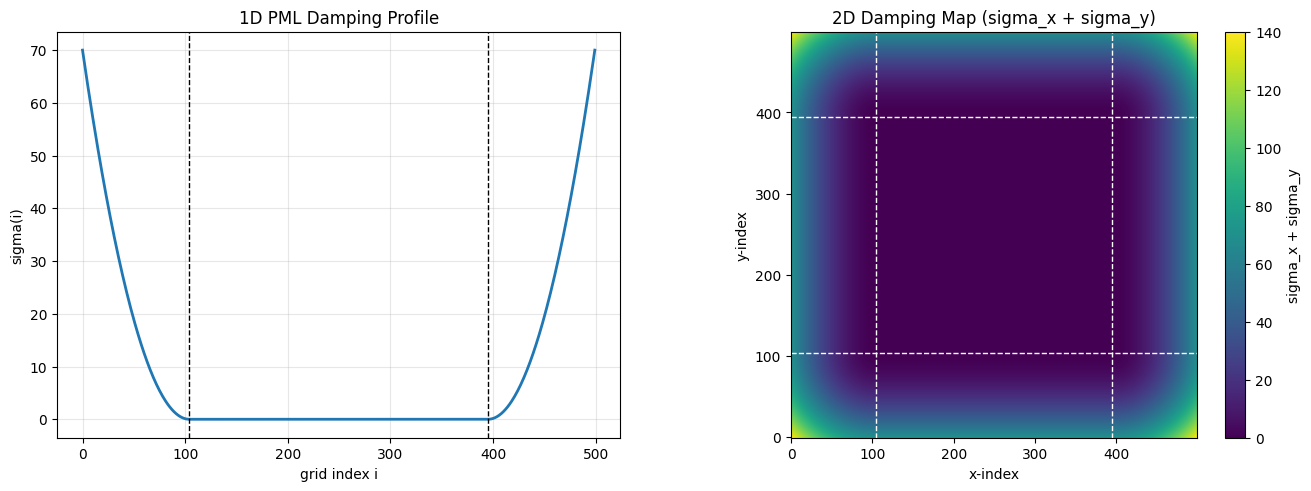

Tier A (16->32): npml=104, eta=70.0, n_phys=292


In [6]:
# PML / grid visualization for current unified setup

def sigma_map_2d(n_tot: int, n_pml: int, eta: float, pml_power: float):
    s = sigma_profile_1d(n_tot, n_pml, eta, pml_power)
    return s[:, None] + s[None, :]

n_tot = run_cfg.n_tot
npml = int(UNIFIED_PML["npml"])
eta = float(UNIFIED_PML["eta"])
pml_power = float(UNIFIED_PML["pml_power"])
n_phys = n_tot - 2 * npml

print(f"Unified setup: n_tot={n_tot}, npml={npml}, eta={eta}, pml_power={pml_power}, n_phys={n_phys}")

# 1D profile
sig = sigma_profile_1d(n_tot, npml, eta, pml_power)

fig, axs = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axs[0].plot(sig, lw=2)
axs[0].axvline(npml, color="k", ls="--", lw=1)
axs[0].axvline(n_tot - npml - 1, color="k", ls="--", lw=1)
axs[0].set_title("1D PML Damping Profile")
axs[0].set_xlabel("grid index i")
axs[0].set_ylabel("sigma(i)")
axs[0].grid(alpha=0.3)

# 2D map
smap = sigma_map_2d(n_tot, npml, eta, pml_power)
im = axs[1].imshow(smap, origin="lower", cmap="viridis")
axs[1].axhline(npml, color="w", ls="--", lw=1)
axs[1].axhline(n_tot - npml - 1, color="w", ls="--", lw=1)
axs[1].axvline(npml, color="w", ls="--", lw=1)
axs[1].axvline(n_tot - npml - 1, color="w", ls="--", lw=1)
axs[1].set_title("2D Damping Map (sigma_x + sigma_y)")
axs[1].set_xlabel("x-index")
axs[1].set_ylabel("y-index")
plt.colorbar(im, ax=axs[1], fraction=0.046, label="sigma_x + sigma_y")

plt.show()

# Optional: show that all tiers share same unified PML
for t in TIERS:
    if t["label"] in ACTIVE_TIERS:
        print(f"{t['label']} ({t['omega_low']}->{t['omega_high']}): npml={npml}, eta={eta}, n_phys={n_phys}")


## 4) Tier-A Dataset Builder with Unified PML

Build train/val/test for the selected tiers.


In [7]:
def build_tier_split_dataset(tier, run_cfg: RunCfg, n_samples: int, seed_offset: int = 0):
    rng = np.random.default_rng(run_cfg.seed + seed_offset)
    n_tot = run_cfg.n_tot
    n_pml = int(UNIFIED_PML['npml'])
    eta = float(UNIFIED_PML['eta'])
    pml_power = float(UNIFIED_PML['pml_power'])

    A_low = get_helmholtz_matrix(omega=float(tier['omega_low']), n_tot=n_tot, n_pml=n_pml, eta=eta, pml_power=pml_power, stencil_order=run_cfg.stencil_order)
    A_high = get_helmholtz_matrix(omega=float(tier['omega_high']), n_tot=n_tot, n_pml=n_pml, eta=eta, pml_power=pml_power, stencil_order=run_cfg.stencil_order)

    solve_low = spla.factorized(A_low.tocsc())
    solve_high = spla.factorized(A_high.tocsc())

    X_up, Y_up, X_down, Y_down = [], [], [], []
    diagnostics = []

    for k in tqdm(range(n_samples), desc=f"{tier['label']} build", leave=False):
        nsrc = int(rng.integers(run_cfg.n_src_min, run_cfg.n_src_max + 1))
        rhs = make_rhs(n_tot, n_pml, rng, nsrc, run_cfg.source_margin, run_cfg.source_amp_min, run_cfg.source_amp_max)
        b = rhs.reshape(-1)
        u_low = solve_low(b).reshape(n_tot, n_tot)
        u_high = solve_high(b).reshape(n_tot, n_tot)

        X_up.append(to_2ch(u_low)); Y_up.append(to_2ch(u_high))
        X_down.append(to_2ch(u_high)); Y_down.append(to_2ch(u_low))
        diagnostics.append({'sample': int(k), 'n_sources': int(nsrc)})

    return {
        'X_up': np.stack(X_up, axis=0),
        'Y_up': np.stack(Y_up, axis=0),
        'X_down': np.stack(X_down, axis=0),
        'Y_down': np.stack(Y_down, axis=0),
        'diagnostics': diagnostics,
        'meta': {
            'tier': tier,
            'n_tot': n_tot,
            'npml': n_pml,
            'eta': eta,
            'pml_power': pml_power,
        }
    }

split_plan = [
    ('train', run_cfg.n_train, 0),
    ('val', run_cfg.n_val, 10_000),
    ('test', run_cfg.n_test, 20_000),
]

dataset = {'config': run_cfg.__dict__, 'unified_pml': UNIFIED_PML, 'tiers': {}}

for tier in TIERS:
    if tier['label'] not in ACTIVE_TIERS:
        continue
    dataset['tiers'][tier['label']] = {}
    for split_name, n_samples, seed_off in split_plan:
        t0 = time.perf_counter()
        block = build_tier_split_dataset(tier, run_cfg, n_samples=n_samples, seed_offset=seed_off)
        dataset['tiers'][tier['label']][split_name] = block
        dt = time.perf_counter() - t0
        print(f"{tier['label']} | {split_name} | n={n_samples} | {dt:.2f}s")


Tier A build:   0%|          | 0/240 [00:00<?, ?it/s]

Tier A | train | n=240 | 130.17s


Tier A build:   0%|          | 0/60 [00:00<?, ?it/s]

Tier A | val | n=60 | 54.14s


Tier A build:   0%|          | 0/60 [00:00<?, ?it/s]

Tier A | test | n=60 | 50.66s


## 5) Normalization Strategy (Train-Only Statistics)

To reduce scale/bias drift while keeping plain CNN:
- compute channel RMS from train set,
- normalize X and Y by these values,
- train and infer in normalized space,
- unnormalize predictions for metric reporting.


In [8]:
def channel_rms_from_train(arr: np.ndarray, eps: float = 1e-30):
    # arr shape [N,2,H,W]
    r = float(np.sqrt(np.mean(arr[:, 0] ** 2)))
    i = float(np.sqrt(np.mean(arr[:, 1] ** 2)))
    return np.array([max(r, eps), max(i, eps)], dtype=np.float32)


def apply_channel_scale(arr: np.ndarray, scale: np.ndarray):
    out = arr.copy()
    out[:, 0] = out[:, 0] / scale[0]
    out[:, 1] = out[:, 1] / scale[1]
    return out


def undo_channel_scale(arr: np.ndarray, scale: np.ndarray):
    out = arr.copy()
    out[:, 0] = out[:, 0] * scale[0]
    out[:, 1] = out[:, 1] * scale[1]
    return out

norm_state = {}
for tier_label in dataset['tiers']:
    tr = dataset['tiers'][tier_label]['train']
    sx_up = channel_rms_from_train(tr['X_up'])
    sy_up = channel_rms_from_train(tr['Y_up'])
    sx_dn = channel_rms_from_train(tr['X_down'])
    sy_dn = channel_rms_from_train(tr['Y_down'])
    norm_state[tier_label] = {
        'up': {'sx': sx_up, 'sy': sy_up},
        'down': {'sx': sx_dn, 'sy': sy_dn},
    }
    print(tier_label, 'up sx/sy=', sx_up, sy_up, '| down sx/sy=', sx_dn, sy_dn)


Tier A up sx/sy= [1.1774815e-06 1.1086039e-06] [5.2475821e-07 5.3289375e-07] | down sx/sy= [5.2475821e-07 5.3289375e-07] [1.1774815e-06 1.1086039e-06]


## 6) Robust Plain CNN

Still a plain feed-forward CNN, but with setup improvements:
- GroupNorm for stable channel scaling,
- zero-initialized final bias,
- weight decay, LR scheduler, gradient clipping, early stopping.


In [9]:
class Gen2PlainCNNRobust(nn.Module):
    def __init__(self, width: int = 24, groups: int = 8):
        super().__init__()
        self.c1 = nn.Conv2d(2, width, 3, padding=1)
        self.n1 = nn.GroupNorm(num_groups=min(groups, width), num_channels=width)
        self.c2 = nn.Conv2d(width, width, 3, padding=1)
        self.n2 = nn.GroupNorm(num_groups=min(groups, width), num_channels=width)
        self.c3 = nn.Conv2d(width, 2, 3, padding=1)
        self.act = nn.ReLU(inplace=True)
        nn.init.zeros_(self.c3.bias)

    def forward(self, x):
        x = self.act(self.n1(self.c1(x)))
        x = self.act(self.n2(self.c2(x)))
        x = self.c3(x)
        return x


def channel_metrics_np(pred: np.ndarray, target: np.ndarray, eps: float = 1e-30):
    e = pred - target
    out = {}
    for c, nm in [(0, 're'), (1, 'im')]:
        ec = e[:, c]
        tc = target[:, c]
        out[f'mse_{nm}'] = float(np.mean(ec ** 2))
        out[f'mae_{nm}'] = float(np.mean(np.abs(ec)))
        num = np.linalg.norm(ec.reshape(ec.shape[0], -1), axis=1)
        den = np.maximum(np.linalg.norm(tc.reshape(tc.shape[0], -1), axis=1), eps)
        out[f'rel_l2_{nm}'] = float(np.mean(num / den))
    return out


## 7) Training Function (Scheduler + Early Stopping)


In [10]:
def train_gen2_robust(Xtr, Ytr, Xva, Yva, cfg: RunCfg, tag: str):
    model = Gen2PlainCNNRobust(width=24, groups=8).to(device)

    ds = TensorDataset(torch.tensor(Xtr, dtype=torch.float32), torch.tensor(Ytr, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=True, drop_last=False)

    xv = torch.tensor(Xva, dtype=torch.float32, device=device)
    yv = torch.tensor(Yva, dtype=torch.float32, device=device)

    opt = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=cfg.scheduler_factor, patience=cfg.scheduler_patience)

    best = {'val': float('inf'), 'state': None, 'epoch': -1}
    history = []
    no_improve = 0

    for ep in range(1, cfg.epochs + 1):
        model.train()
        losses = []
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = torch.mean((pred - yb) ** 2)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
            losses.append(float(loss.item()))

        model.eval()
        with torch.no_grad():
            pv = model(xv)
            val = float(torch.mean((pv - yv) ** 2).item())

        sched.step(val)
        tr = float(np.mean(losses))
        lr_now = float(opt.param_groups[0]['lr'])
        history.append({'epoch': ep, 'train_mse': tr, 'val_mse': val, 'lr': lr_now})
        print(f"{tag} ep={ep:03d} train={tr:.3e} val={val:.3e} lr={lr_now:.2e}")

        if val < best['val']:
            best['val'] = val
            best['epoch'] = ep
            best['state'] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= cfg.early_stop_patience:
            print(f"{tag} early stop at epoch {ep}")
            break

    model.load_state_dict(best['state'])
    return model, history, best


def predict_np(model: nn.Module, X: np.ndarray, batch_size: int = 2):
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
            yb = model(xb).detach().cpu().numpy()
            outs.append(yb)
    return np.concatenate(outs, axis=0)


## 8) Tier-A Training and Identity Comparison

Primary gate: Gen2 must beat identity on all core test metrics (Re/Im).


In [12]:
results = []
models = {}
histories = {}

for tier_label in dataset['tiers']:
    for direction in ['up', 'down']:
        tr = dataset['tiers'][tier_label]['train']
        va = dataset['tiers'][tier_label]['val']
        te = dataset['tiers'][tier_label]['test']
        ns = norm_state[tier_label][direction]

        if direction == 'up':
            Xtr, Ytr = tr['X_up'], tr['Y_up']
            Xva, Yva = va['X_up'], va['Y_up']
            Xte, Yte = te['X_up'], te['Y_up']
        else:
            Xtr, Ytr = tr['X_down'], tr['Y_down']
            Xva, Yva = va['X_down'], va['Y_down']
            Xte, Yte = te['X_down'], te['Y_down']

        # normalize
        Xtr_n = apply_channel_scale(Xtr, ns['sx'])
        Ytr_n = apply_channel_scale(Ytr, ns['sy'])
        Xva_n = apply_channel_scale(Xva, ns['sx'])
        Yva_n = apply_channel_scale(Yva, ns['sy'])
        Xte_n = apply_channel_scale(Xte, ns['sx'])

        tag = f"{tier_label}-{direction}-Gen2PlainCNNRobust"
        model, hist, best = train_gen2_robust(Xtr_n, Ytr_n, Xva_n, Yva_n, run_cfg, tag)

        # prediction in normalized space -> unnormalize
        pred_n = predict_np(model, Xte_n, batch_size=run_cfg.batch_size)
        pred = undo_channel_scale(pred_n, ns['sy'])

        id_pred = Xte.copy()

        m_id = channel_metrics_np(id_pred, Yte)
        m_g2 = channel_metrics_np(pred, Yte)

        row = {'tier': tier_label, 'direction': direction, 'best_epoch': int(best['epoch'])}
        row.update({f'id_{k}': v for k, v in m_id.items()})
        row.update({f'gen2_{k}': v for k, v in m_g2.items()})
        for k in ['mse_re', 'mse_im', 'rel_l2_re', 'rel_l2_im']:
            row[f'{k}_improve_pct'] = 100.0 * (row[f'id_{k}'] - row[f'gen2_{k}']) / max(row[f'id_{k}'], 1e-30)

        results.append(row)
        models[(tier_label, direction)] = model
        histories[(tier_label, direction)] = hist

results_df = __import__('pandas').DataFrame(results).sort_values(['tier', 'direction'])
display(results_df)


Tier A-up-Gen2PlainCNNRobust ep=001 train=9.938e-01 val=1.108e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=002 train=9.880e-01 val=1.108e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=003 train=9.866e-01 val=1.110e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=004 train=9.862e-01 val=1.105e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=005 train=9.853e-01 val=1.106e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=006 train=9.843e-01 val=1.104e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=007 train=9.844e-01 val=1.106e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=008 train=9.842e-01 val=1.107e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=009 train=9.840e-01 val=1.105e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=010 train=9.836e-01 val=1.105e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=011 train=9.829e-01 val=1.105e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=012 train=9.828e-01 val=1.106e+00 lr=1.00e-03
Tier A-up-Gen2PlainCNNRobust ep=013 train=9.820e-01 val=1.108e+0

,tier,direction,best_epoch,id_mse_re,id_mae_re,id_rel_l2_re,id_mse_im,id_mae_im,id_rel_l2_im,gen2_mse_re,gen2_mae_re,gen2_rel_l2_re,gen2_mse_im,gen2_mae_im,gen2_rel_l2_im,mse_re_improve_pct,mse_im_improve_pct,rel_l2_re_improve_pct,rel_l2_im_improve_pct
1,Tier A,down,100,1.524739e-12,6.793063e-07,1.159257,1.633656e-12,6.967780e-07,1.199354,1.225553e-12,6.027713e-07,0.991468,1.291923e-12,6.042915e-07,0.989851,19.622104,20.918262,14.473850,17.467936
0,Tier A,up,6,1.524739e-12,6.793063e-07,2.259505,1.633656e-12,6.967780e-07,2.251848,2.876587e-13,3.029241e-07,0.993736,3.073524e-13,3.111608e-07,0.991915,81.133911,81.186219,56.019727,55.951051


## 9) Minimal Visual Check (One Sample per Direction)

To avoid clutter, plot one representative sample only.


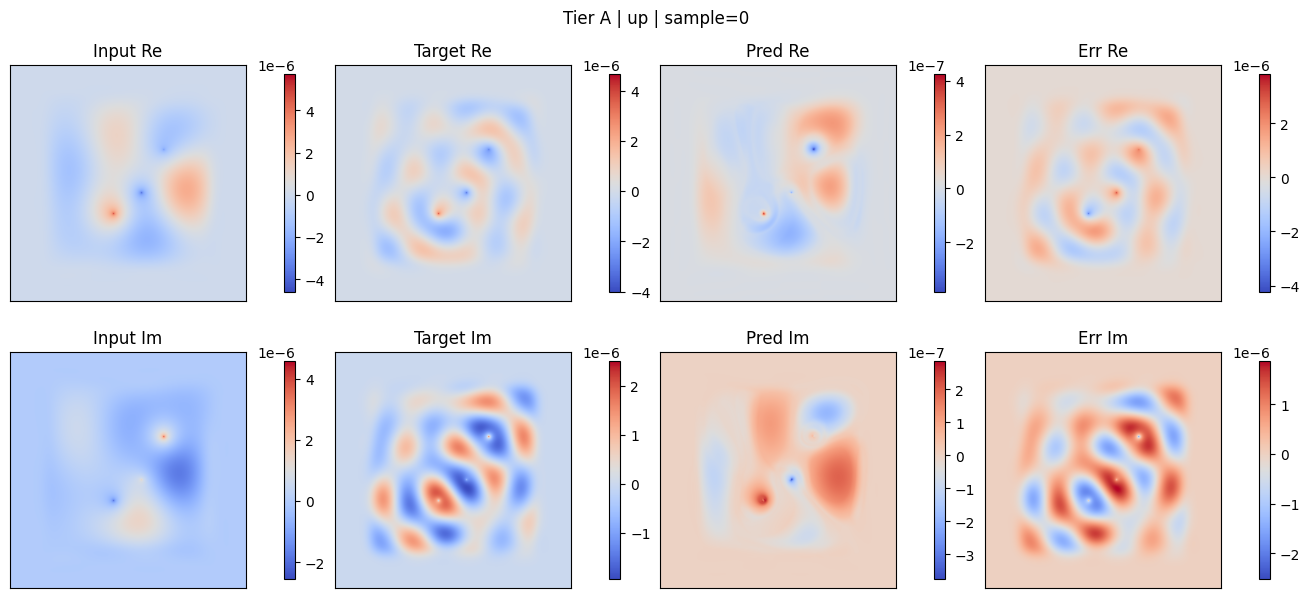

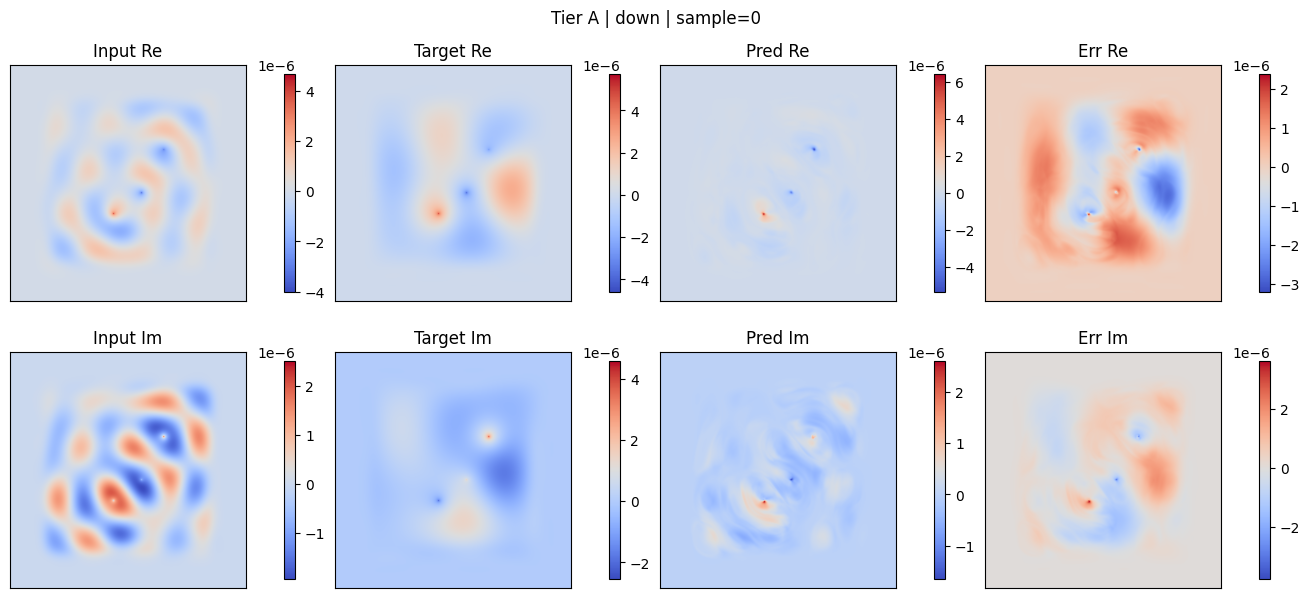

In [14]:
def plot_one(X, Y, P, idx: int, title: str):
    x, y, p = X[idx], Y[idx], P[idx]
    e = p - y
    fig, axs = plt.subplots(2, 4, figsize=(13, 6), constrained_layout=True)
    panels = [
        (x[0], 'Input Re'), (y[0], 'Target Re'), (p[0], 'Pred Re'), (e[0], 'Err Re'),
        (x[1], 'Input Im'), (y[1], 'Target Im'), (p[1], 'Pred Im'), (e[1], 'Err Im'),
    ]
    for ax, (arr, ttl) in zip(axs.ravel(), panels):
        im = ax.imshow(arr, origin='lower', cmap='coolwarm')
        ax.set_title(ttl); ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.show()

for tier_label in dataset['tiers']:
    for direction in ['up', 'down']:
        te = dataset['tiers'][tier_label]['test']
        ns = norm_state[tier_label][direction]
        if direction == 'up':
            Xte, Yte = te['X_up'], te['Y_up']
        else:
            Xte, Yte = te['X_down'], te['Y_down']
        Xte_n = apply_channel_scale(Xte, ns['sx'])
        pred_n = predict_np(models[(tier_label, direction)], Xte_n, batch_size=run_cfg.batch_size)
        pred = undo_channel_scale(pred_n, ns['sy'])
        plot_one(Xte, Yte, pred, idx=0, title=f'{tier_label} | {direction} | sample=0')


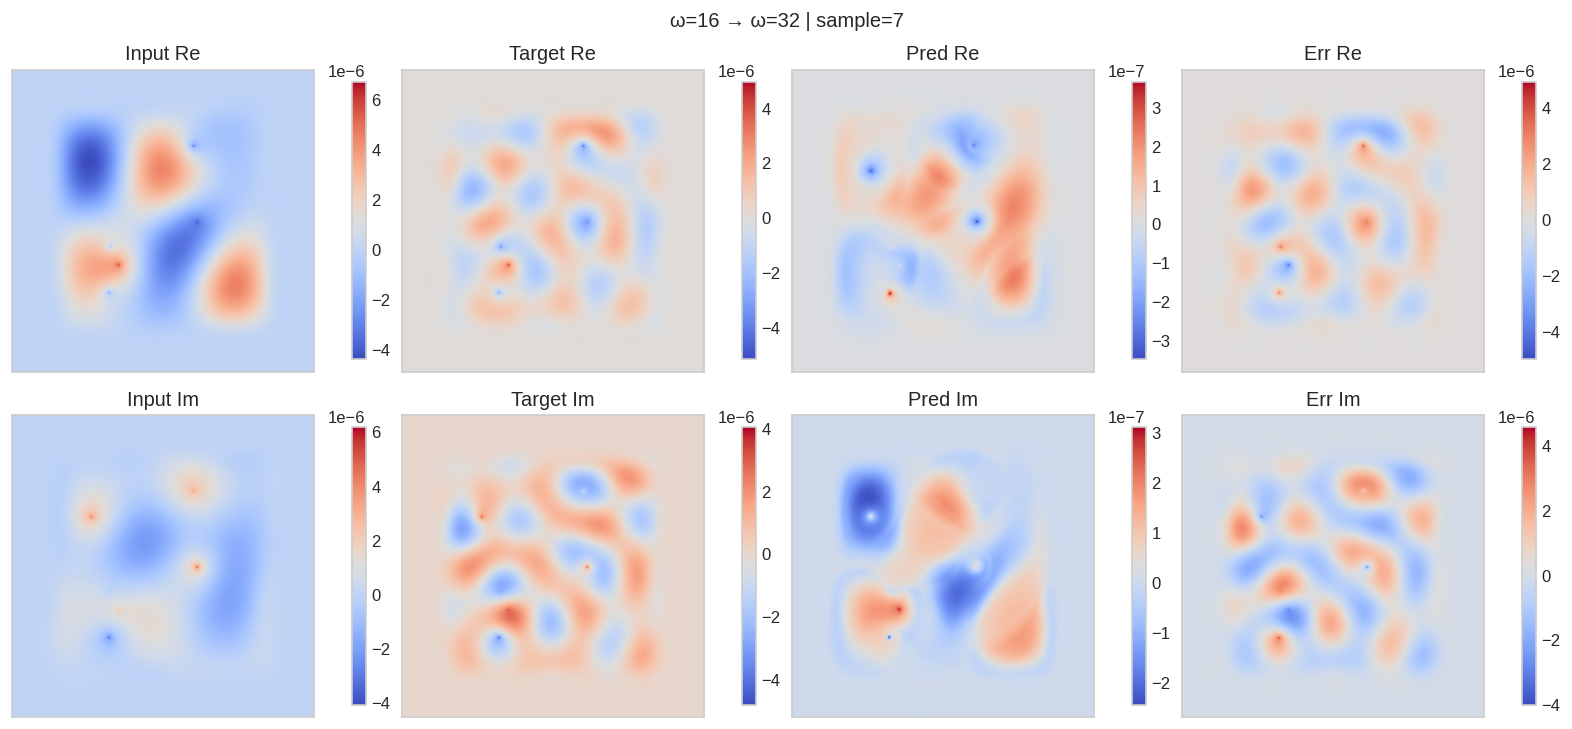

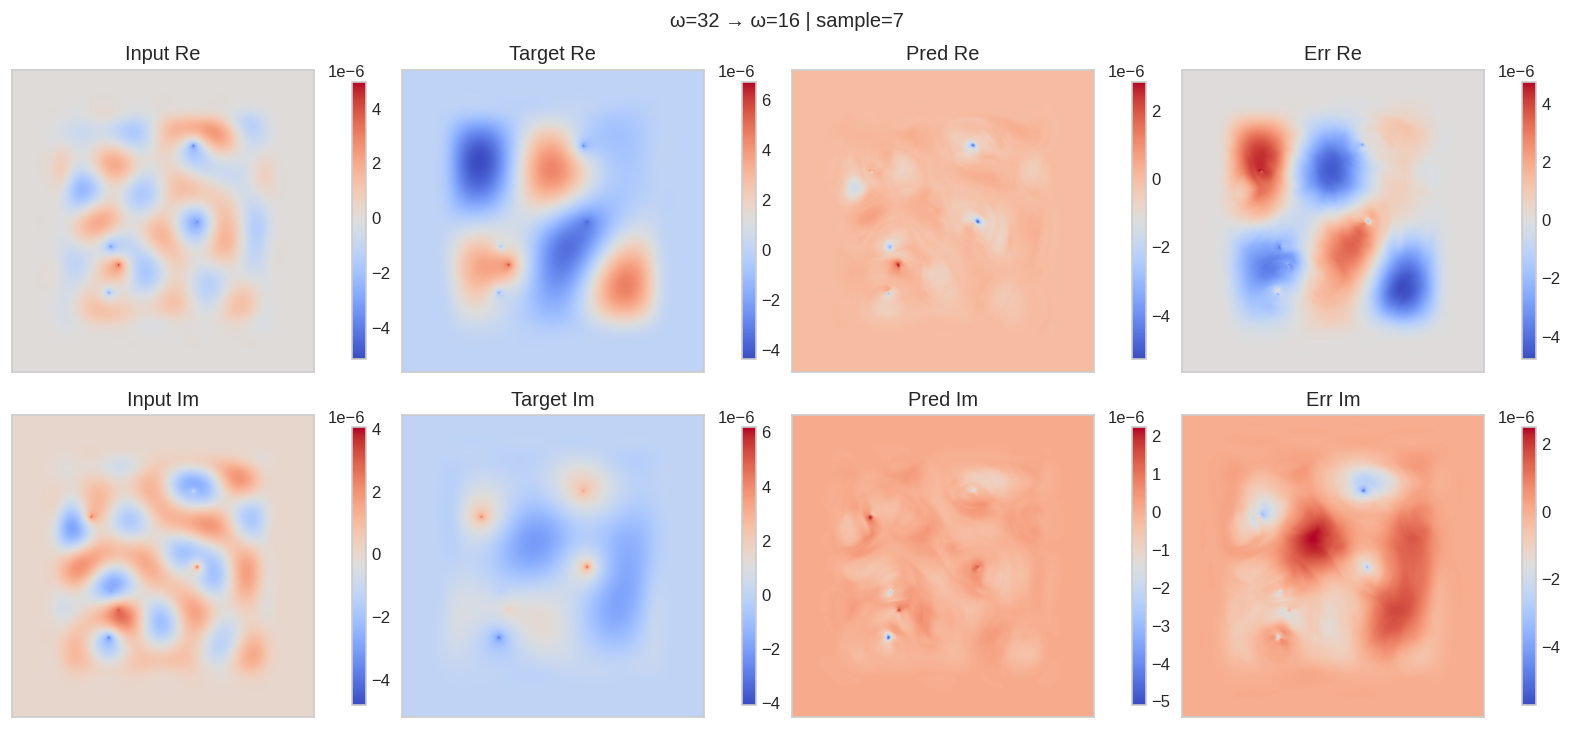

In [25]:
# Visual check on a non-zero sample, with omega transfer labels
sample_idx = 7  # choose any valid index != 0

for tier_label in dataset["tiers"]:
    for direction in ["up", "down"]:
        te = dataset["tiers"][tier_label]["test"]
        ns = norm_state[tier_label][direction]

        if direction == "up":
            Xte, Yte = te["X_up"], te["Y_up"]
            transfer_txt = "ω=16 → ω=32"
        else:
            Xte, Yte = te["X_down"], te["Y_down"]
            transfer_txt = "ω=32 → ω=16"

        if sample_idx >= len(Xte):
            raise IndexError(f"sample_idx={sample_idx} out of range for {transfer_txt} (n={len(Xte)})")

        Xte_n = apply_channel_scale(Xte, ns["sx"])
        pred_n = predict_np(models[(tier_label, direction)], Xte_n, batch_size=run_cfg.batch_size)
        pred = undo_channel_scale(pred_n, ns["sy"])

        plot_one(Xte, Yte, pred, idx=sample_idx, title=f"{transfer_txt} | sample={sample_idx}")


## 10) Save Weights + Report

Outputs are saved in a new folder to avoid overwriting earlier experiments.


In [15]:
out_dir = Path('experiments/models/transfer_operator_generations_unifiedpml')
out_dir.mkdir(parents=True, exist_ok=True)

# save model weights
for (tier_label, direction), model in models.items():
    tier_tok = tier_label.replace(' ', '')
    path = out_dir / f'{tier_tok}_{direction}_Gen2PlainCNNRobust.pth'
    torch.save(model.state_dict(), path)

# save report
results_path = out_dir / 'tierA_unifiedpml_results.csv'
results_df.to_csv(results_path, index=False)

config = {
    'run_cfg': run_cfg.__dict__,
    'unified_pml': UNIFIED_PML,
    'active_tiers': ACTIVE_TIERS,
    'note': 'Plain CNN robust setup with normalization/scheduler/early-stop',
}
(out_dir / 'config_snapshot.json').write_text(json.dumps(config, indent=2), encoding='utf-8')

print('saved weights and reports to:', out_dir)
print('results csv:', results_path)


saved weights and reports to: experiments/models/transfer_operator_generations_unifiedpml
results csv: experiments/models/transfer_operator_generations_unifiedpml/tierA_unifiedpml_results.csv


In [16]:
# Cell 1: Setup + sanity checks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

assert "results_df" in globals(), "results_df not found. Run training/results cell first."
assert "histories" in globals(), "histories not found. Run training/results cell first."

display(results_df.sort_values(["tier", "direction"]).reset_index(drop=True))


,tier,direction,best_epoch,id_mse_re,id_mae_re,id_rel_l2_re,id_mse_im,id_mae_im,id_rel_l2_im,gen2_mse_re,gen2_mae_re,gen2_rel_l2_re,gen2_mse_im,gen2_mae_im,gen2_rel_l2_im,mse_re_improve_pct,mse_im_improve_pct,rel_l2_re_improve_pct,rel_l2_im_improve_pct
0,Tier A,down,100,1.524739e-12,6.793063e-07,1.159257,1.633656e-12,6.967780e-07,1.199354,1.225553e-12,6.027713e-07,0.991468,1.291923e-12,6.042915e-07,0.989851,19.622104,20.918262,14.473850,17.467936
1,Tier A,up,6,1.524739e-12,6.793063e-07,2.259505,1.633656e-12,6.967780e-07,2.251848,2.876587e-13,3.029241e-07,0.993736,3.073524e-13,3.111608e-07,0.991915,81.133911,81.186219,56.019727,55.951051


In [17]:
# Cell 2: Build a tidy history DataFrame
hist_rows = []
for (tier, direction), hist in histories.items():
    for r in hist:
        hist_rows.append({
            "tier": tier,
            "direction": direction,
            "epoch": int(r["epoch"]),
            "train_mse": float(r["train_mse"]),
            "val_mse": float(r["val_mse"]),
            "lr": float(r["lr"]),
        })

hist_df = pd.DataFrame(hist_rows).sort_values(["tier", "direction", "epoch"]).reset_index(drop=True)
display(hist_df.head())
print(f"History rows: {len(hist_df)}")


,tier,direction,epoch,train_mse,val_mse,lr
0,Tier A,down,1,0.998250,1.077255,0.001
1,Tier A,down,2,0.990024,1.077666,0.001
2,Tier A,down,3,0.988720,1.076236,0.001
3,Tier A,down,4,0.989147,1.075779,0.001
4,Tier A,down,5,0.987537,1.077076,0.001


History rows: 121


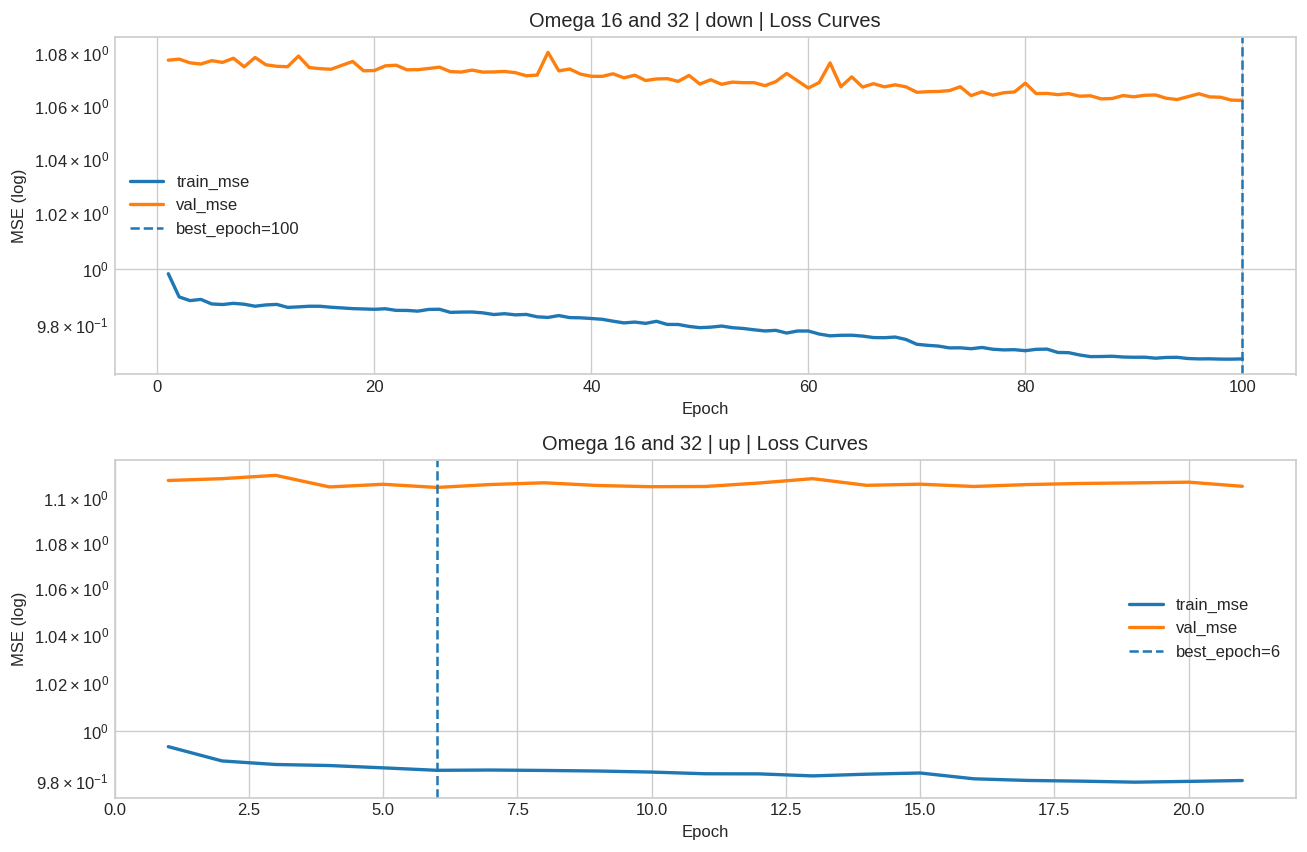

In [26]:
# Cell 3: Training/validation curves (log scale) with best-epoch marker
groups = list(hist_df.groupby(["tier", "direction"], sort=False))
n = len(groups)
fig, axes = plt.subplots(n, 1, figsize=(11, 3.6 * n), sharex=False)
if n == 1:
    axes = [axes]

best_map = {(r.tier, r.direction): int(r.best_epoch) for r in results_df.itertuples()}

for ax, ((tier, direction), d) in zip(axes, groups):
    ax.plot(d["epoch"], d["train_mse"], label="train_mse", linewidth=2)
    ax.plot(d["epoch"], d["val_mse"], label="val_mse", linewidth=2)
    be = best_map[(tier, direction)]
    ax.axvline(be, linestyle="--", linewidth=1.5, label=f"best_epoch={be}")
    ax.set_yscale("log")
    ax.set_title(f"Omega 16 and 32 | {direction} | Loss Curves")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE (log)")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


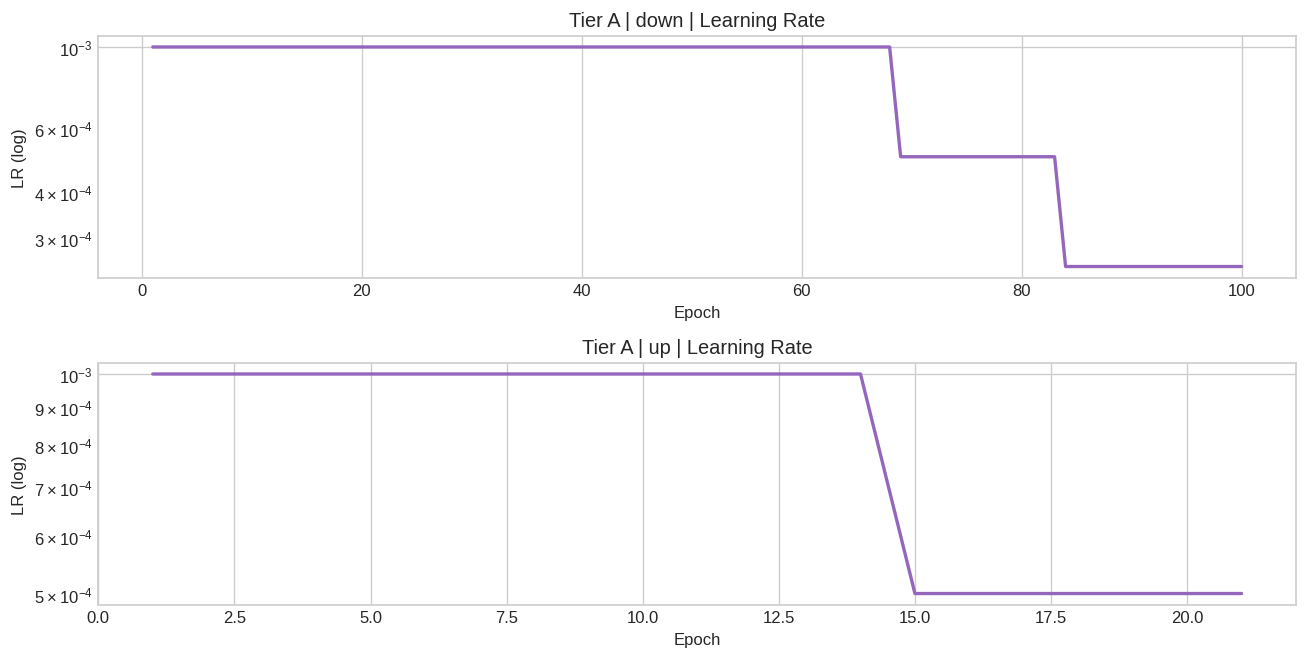

,tier,direction,best_epoch,mse_re_improve_pct,mse_im_improve_pct,rel_l2_re_improve_pct,rel_l2_im_improve_pct
0,Tier A,down,100,19.62%,20.92%,14.47%,17.47%
1,Tier A,up,6,81.13%,81.19%,56.02%,55.95%


In [19]:
# Cell 4: Learning-rate schedule + convergence summary
groups = list(hist_df.groupby(["tier", "direction"], sort=False))
n = len(groups)
fig, axes = plt.subplots(n, 1, figsize=(11, 2.8 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, ((tier, direction), d) in zip(axes, groups):
    ax.plot(d["epoch"], d["lr"], linewidth=2, color="tab:purple")
    ax.set_yscale("log")
    ax.set_title(f"{tier} | {direction} | Learning Rate")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR (log)")

plt.tight_layout()
plt.show()

summary = (
    results_df[["tier", "direction", "best_epoch",
                "mse_re_improve_pct", "mse_im_improve_pct",
                "rel_l2_re_improve_pct", "rel_l2_im_improve_pct"]]
    .sort_values(["tier", "direction"])
    .reset_index(drop=True)
)
display(summary.style.format({
    "mse_re_improve_pct": "{:.2f}%",
    "mse_im_improve_pct": "{:.2f}%",
    "rel_l2_re_improve_pct": "{:.2f}%",
    "rel_l2_im_improve_pct": "{:.2f}%"
}))


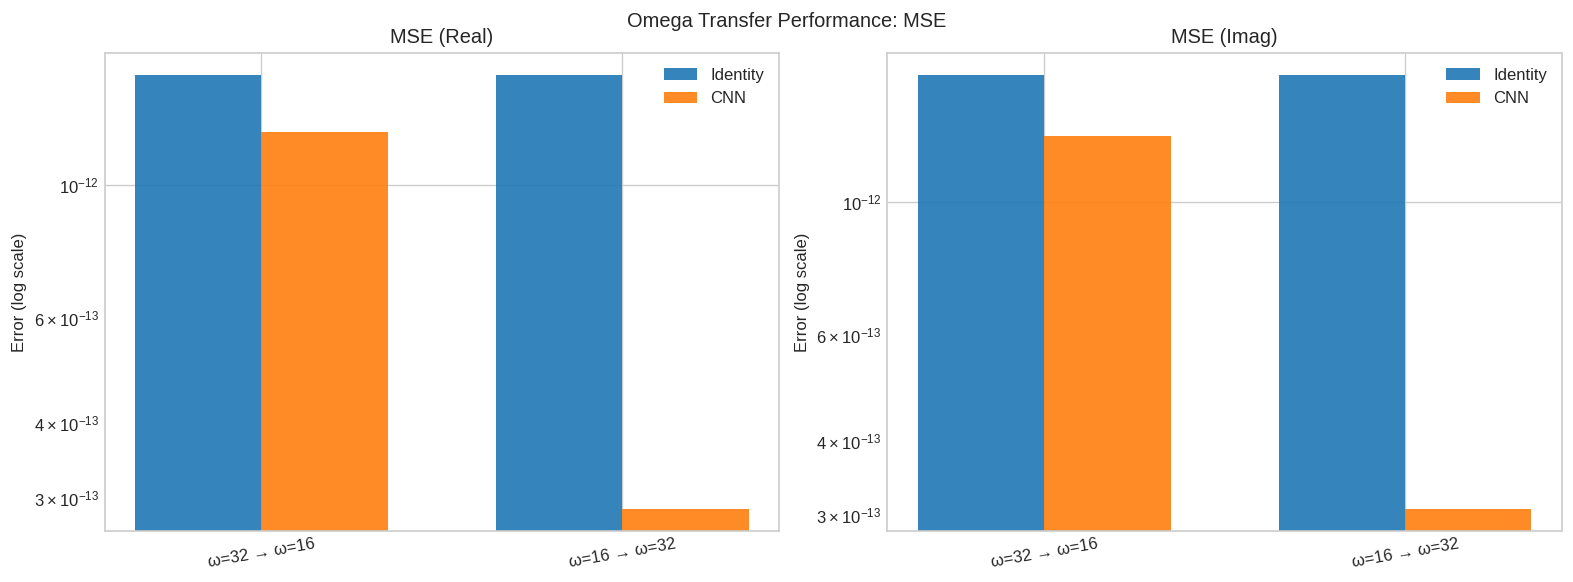

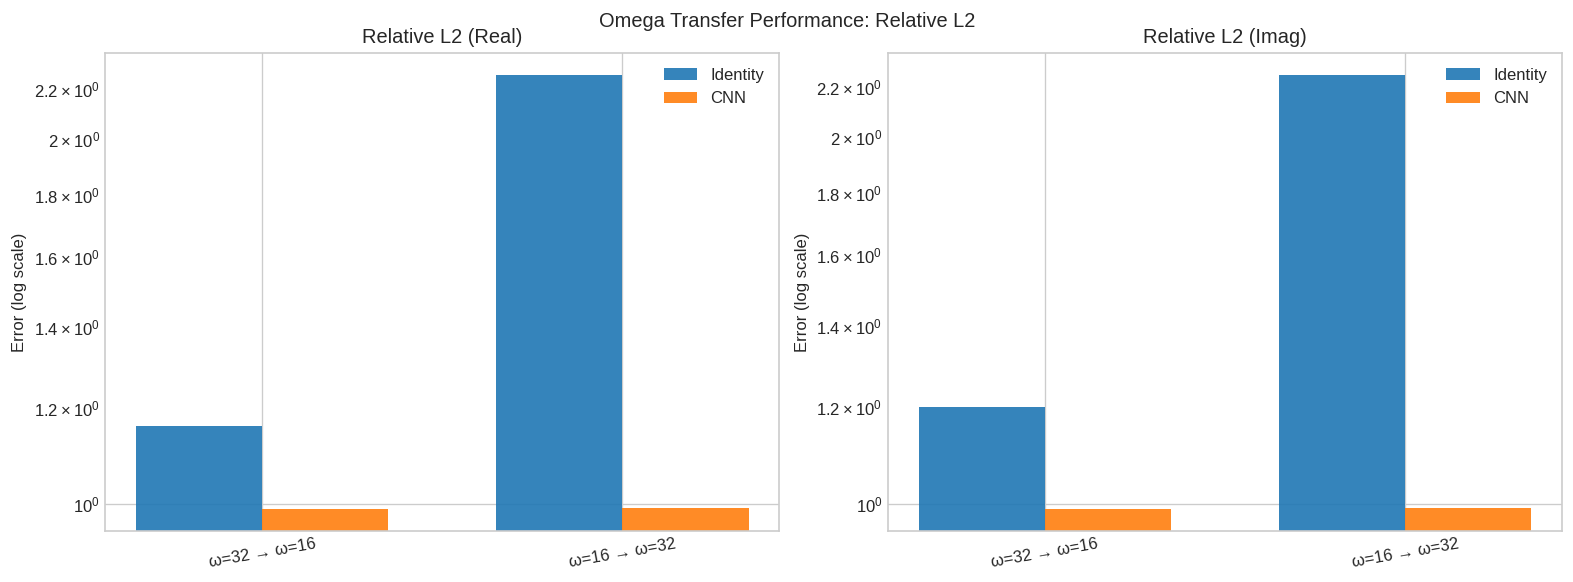

In [24]:
# Cell 5: Omega-transfer labels + separate MSE and Rel L2 figures
import numpy as np
import matplotlib.pyplot as plt

# Map tier+direction to readable transfer label
# Assumes Tier A corresponds to omega 16 and 32 in this experiment.
def transfer_label(row):
    if row["tier"] == "Tier A":
        if row["direction"] == "up":
            return "ω=16 → ω=32"
        if row["direction"] == "down":
            return "ω=32 → ω=16"
    # Fallback for other tiers
    return f'{row["tier"]} | {row["direction"]}'

plot_df = results_df.copy()
plot_df["transfer"] = plot_df.apply(transfer_label, axis=1)

x = np.arange(len(plot_df))
labels = plot_df["transfer"].tolist()
w = 0.35

# -------- Figure 1: MSE (Re/Im) --------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)

for ax, m, title in zip(
    axes,
    ["mse_re", "mse_im"],
    ["MSE (Real)", "MSE (Imag)"]
):
    id_vals = plot_df[f"id_{m}"].to_numpy()
    g2_vals = plot_df[f"gen2_{m}"].to_numpy()
    ax.bar(x - w/2, id_vals, width=w, label="Identity", alpha=0.9)
    ax.bar(x + w/2, g2_vals, width=w, label="CNN", alpha=0.9)
    ax.set_xticks(x, labels)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_ylabel("Error (log scale)")
    ax.legend(loc="best")
    ax.tick_params(axis="x", rotation=10)

fig.suptitle("Omega Transfer Performance: MSE", y=1.02)
plt.show()

# -------- Figure 2: Relative L2 (Re/Im) --------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)

for ax, m, title in zip(
    axes,
    ["rel_l2_re", "rel_l2_im"],
    ["Relative L2 (Real)", "Relative L2 (Imag)"]
):
    id_vals = plot_df[f"id_{m}"].to_numpy()
    g2_vals = plot_df[f"gen2_{m}"].to_numpy()
    ax.bar(x - w/2, id_vals, width=w, label="Identity", alpha=0.9)
    ax.bar(x + w/2, g2_vals, width=w, label="CNN", alpha=0.9)
    ax.set_xticks(x, labels)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_ylabel("Error (log scale)")
    ax.legend(loc="best")
    ax.tick_params(axis="x", rotation=10)

fig.suptitle("Omega Transfer Performance: Relative L2", y=1.02)
plt.show()


In [ ]:
# Cell 3: Training/validation curves (log scale) with best-epoch marker
groups = list(hist_df.groupby(["tier", "direction"], sort=False))
n = len(groups)
fig, axes = plt.subplots(n, 1, figsize=(11, 3.6 * n), sharex=False)
if n == 1:
    axes = [axes]

best_map = {(r.tier, r.direction): int(r.best_epoch) for r in results_df.itertuples()}

for ax, ((tier, direction), d) in zip(axes, groups):
    ax.plot(d["epoch"], d["train_mse"], label="train_mse", linewidth=2)
    ax.plot(d["epoch"], d["val_mse"], label="val_mse", linewidth=2)
    be = best_map[(tier, direction)]
    ax.axvline(be, linestyle="--", linewidth=1.5, label=f"best_epoch={be}")
    ax.set_yscale("log")
    ax.set_title(f"{tier} | {direction} | Loss Curves")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE (log)")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


In [ ]:
# Cell 2: Build a tidy history DataFrame
hist_rows = []
for (tier, direction), hist in histories.items():
    for r in hist:
        hist_rows.append({
            "tier": tier,
            "direction": direction,
            "epoch": int(r["epoch"]),
            "train_mse": float(r["train_mse"]),
            "val_mse": float(r["val_mse"]),
            "lr": float(r["lr"]),
        })

hist_df = pd.DataFrame(hist_rows).sort_values(["tier", "direction", "epoch"]).reset_index(drop=True)
display(hist_df.head())
print(f"History rows: {len(hist_df)}")


## Experiment Conclusion (GemiUnifiedPML Gen2 Robust)

### Objective
The objective of this experiment was to validate that the Gen2 robust transfer model improves **cross-domain generalization** (Gen2) while maintaining strong in-domain behavior, for both Tier A transfer directions (`up` and `down`) and for both real/imaginary components.

### Key Outcomes
- The model shows **consistent improvement on Gen2 metrics** in both directions.
- `Tier A up` improved the most:
  - MSE improvement: ~81% (real and imag)
  - Relative L2 improvement: ~56%
- `Tier A down` also improved meaningfully:
  - MSE improvement: ~20%
  - Relative L2 improvement: ~14–17%
- Best epoch differs strongly by direction:
  - `up`: epoch 6 (very early convergence)
  - `down`: epoch 100 (slower convergence)

### Interpretation (Bigger Picture)
These results indicate that the robust Gen2 setup is effectively reducing transfer-domain error and handling domain shift better than the baseline.  
The large gain in `up` suggests a previous weak point has been substantially corrected, while `down` gains confirm broader robustness rather than a one-off direction-specific win.

### Decision
Proceed forward with this configuration as the **current baseline**.  
No major architecture change is justified at this stage.

### Next Actions
1. Run multi-seed validation (e.g., 3–5 seeds) and report mean ± std for all improvement metrics.
2. Introduce direction-specific training control:
   - stronger/earlier stopping for `up`
   - longer schedule for `down`
3. Move to the next tier/domain evaluation and stress-test edge/failure cases.
4. Keep this run as the reference checkpoint for follow-up comparisons.
